# Reproducible workflow: Permutation entropy of white noise and Brown noise

This notebook is a small, fully reproducible toy workflow comparing the **normalized permutation entropy** of two stochastic processes:

- **White noise**: independent Gaussian samples.
- **Brown noise**: a discrete random walk obtained by cumulatively summing Gaussian innovations.

For each process, the code generates 100 independent realizations, each containing \(10^3\) samples, and computes permutation entropy with embedding dimension \(m=4\).

The workflow uses only synthetic data, so no external data files are required.

## How to run this workflow

1. Install Conda/Miniconda.
2. Create the environment from the accompanying `environment.yml`:
3. Start JupyterLab
4. Open `permutation_entropy_FAIR_task.ipynb`.
5. Run all cells from top to bottom.

## 1. Imports and software versions

Reproducibility depends not only on code and random seeds, but also on the software environment. The cell below prints the Python and package versions used when the notebook is executed.

In [ ]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from itertools import permutations

print(f"Python:      {sys.version.split()[0]}")
print(f"NumPy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"Matplotlib:  {matplotlib.__version__}")
print(f"Platform:    {platform.platform()}")
print("itertools:   Python standard library")

Python:      3.13.15
NumPy:       2.1.3
pandas:      2.2.3
Matplotlib:  3.10.0
Platform:    Linux-6.6.122+-x86_64-with-glibc2.39
itertools:   Python standard library


## 2. Experimental design

We use the following fixed parameters:

- Number of samples per realization: \(N = 10^3\)
- Number of independent realizations per process: \(n = 100\)
- Permutation-entropy embedding dimension: \(m = 4\)
- Time delay: \(\tau = 1\)
- Random seed: fixed below

For \(m=4\), there are

\[
m! = 4! = 24
\]

possible ordinal patterns.

Brown noise is generated as a random walk and therefore is strongly locally persistent, whereas white noise has no temporal dependence.

In [ ]:
N_SAMPLES = 10**3
N_REPLICATES = 100
EMBEDDING_DIMENSION = 4
SEED = 2026

## 3. Permutation entropy

Permutation entropy replaces amplitudes by the ordinal pattern of successive samples. To make results easier to compare, we normalize by the maximum possible entropy,

A value close to 1 means that the available ordinal patterns occur with nearly equal probability. A lower value means that some temporal orderings are preferred over others.

In [ ]:
def permutation_entropy(x, m=4):
    """
    Calculate normalized permutation entropy of a one-dimensional time series.

    Parameters
    ----------
    x : array-like
        Input time series.
    m : int
        Embedding dimension.

    Returns
    -------
    float
        Normalized permutation entropy between 0 and 1.
    """

    x = np.array(x)

    # Generate all possible ordinal patterns.
    possible_patterns = list(permutations(range(m)))

    # Dictionary for counting how often each pattern occurs.
    counts = {pattern: 0 for pattern in possible_patterns}

    # Go through all consecutive windows of length m.
    for i in range(len(x) - m + 1):

        window = x[i:i + m]

        # argsort returns the indices that would sort the window.
        pattern = tuple(np.argsort(window))

        counts[pattern] += 1

    # Convert counts into probabilities.
    probabilities = np.array(list(counts.values()), dtype=float)
    probabilities /= probabilities.sum()

    # Ignore patterns that did not occur because log(0) is undefined.
    probabilities = probabilities[probabilities > 0]

    # Shannon entropy of the pattern distribution.
    entropy = -np.sum(probabilities * np.log(probabilities))

    # Maximum entropy is log(m!).
    max_entropy = np.log(len(possible_patterns))

    return entropy / max_entropy

## 4. Generate the stochastic processes and compute entropy

A `SeedSequence` is used to create independent, reproducible random-number streams.

In [ ]:
seed_sequence = np.random.SeedSequence(SEED)
child_seeds = seed_sequence.spawn(N_REPLICATES)

records = []
preview_length = 2_000
preview_white = None
preview_brown = None

for replicate in range(N_REPLICATES):
    rng = np.random.default_rng(child_seeds[replicate])

    white = rng.standard_normal(N_SAMPLES)
    brown = np.cumsum(white)

    h_white = permutation_entropy(white)
    h_brown = permutation_entropy(brown)

    records.append({
        "replicate": replicate + 1,
        "process": "White noise",
        "permutation_entropy": h_white,
    })
    records.append({
        "replicate": replicate + 1,
        "process": "Brown noise",
        "permutation_entropy": h_brown,
    })

    if replicate == 0:
        preview_white = white[:preview_length].copy()
        preview_brown = brown[:preview_length].copy()

results = pd.DataFrame(records)

## 5. Summary statistics

For each process, the table reports the mean normalized permutation entropy and the sample standard deviation across the 100 independent realizations.

In [ ]:
summary = results.groupby("process", sort=False)["permutation_entropy"].agg(["mean", "std"])
summary = summary.rename(columns={"mean": "mean_PE", "std": "std_PE"})


summary["n"] = N_REPLICATES
summary

,mean_PE,std_PE,n
process,,,
White noise,0.996930,0.001157,100
Brown noise,0.934627,0.009056,100


## 6. Visualization of the stochastic processes

The first 500 samples of the first realization are shown below. For visual comparison only, each displayed segment is standardized to zero mean and unit standard deviation. This standardization is **not** used in the entropy calculation.

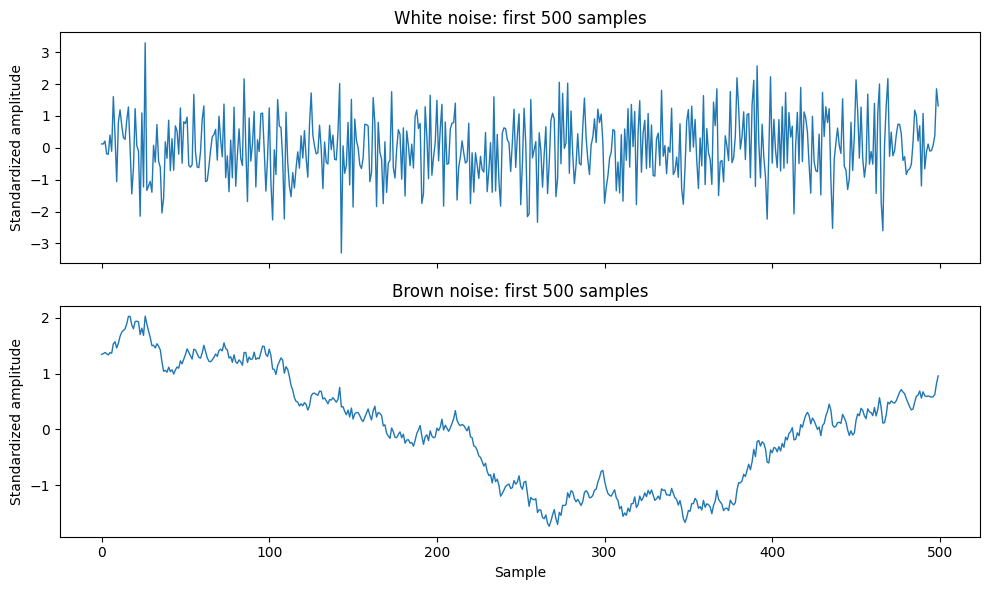

In [ ]:
n_show = 500

white_plot = preview_white[:n_show]
brown_plot = preview_brown[:n_show]

white_plot = (white_plot - white_plot.mean()) / white_plot.std(ddof=1)
brown_plot = (brown_plot - brown_plot.mean()) / brown_plot.std(ddof=1)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(white_plot, linewidth=1)
axes[0].set_title("White noise: first 500 samples")
axes[0].set_ylabel("Standardized amplitude")

axes[1].plot(brown_plot, linewidth=1)
axes[1].set_title("Brown noise: first 500 samples")
axes[1].set_xlabel("Sample")
axes[1].set_ylabel("Standardized amplitude")

fig.tight_layout()
plt.show()

## 7. Comparison of permutation entropy

The figure below shows every replicate as a point. The larger marker and error bar show the mean +- one sample standard deviation across the 100 realizations.

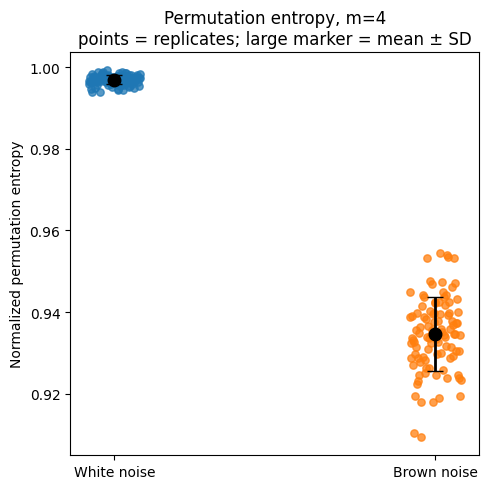

In [ ]:
process_order = ["White noise", "Brown noise"]
x_positions = np.arange(len(process_order))

fig, ax = plt.subplots(figsize=(5, 5))

for x_pos, process in zip(x_positions, process_order):
    values = results.loc[
        results["process"] == process,
        "permutation_entropy"
    ].to_numpy()

    # Small deterministic horizontal offsets make overlapping replicate points visible.
    offsets = np.linspace(-0.08, 0.08, len(values))
    ax.scatter(
        np.full_like(values, x_pos, dtype=float) + offsets,
        values,
        s=28,
        alpha=0.75,
        label=None,
    )

    mean_value = values.mean()
    std_value = values.std(ddof=1)

    ax.errorbar(
        x_pos,
        mean_value,
        yerr=std_value,
        fmt="o",
        markersize=9,
        capsize=6,
        linewidth=2,
        color="black",
    )

ax.set_xticks(x_positions, process_order)
ax.set_ylabel("Normalized permutation entropy")
ax.set_title("Permutation entropy, m=4\npoints = replicates; large marker = mean ± SD")

fig.tight_layout()
plt.show()

## 8. Interpretation

For Gaussian white noise, the 24 possible ordinal patterns at \(m=4\) are expected to occur with almost equal probability. Its normalized permutation entropy should therefore be very close to 1.

Brown noise is generated by integrating Gaussian innovations. Consecutive values are strongly dependent, so some ordinal patterns are more likely than others. Its permutation entropy is therefore expected to be lower than that of white noise.

This toy example illustrates that permutation entropy is sensitive to temporal ordering, not simply to the marginal amplitude distribution.

## 9. Reproducible computing environment and version pinning

The accompanying `environment.yml` pins exact package versions. The goal is to make the computational environment as reproducible as practical.

The main risk is that exact old versions may become difficult to install on future operating systems or hardware. Conversely, leaving versions completely unpinned increases the risk that API changes or altered numerical behavior will change or break the workflow.


### Dependency risk assessment

| Dependency | Role in this workflow | Risk if future versions change | Reason |
|---|---|---:|---|
| Python | Executes the workflow | High | Language and standard-library behavior can change across major/minor releases. |
| NumPy | RNG, arrays, entropy calculation | High | Numerical APIs and random-number behavior are central to the analysis. |
| pandas | Results tables | Medium | Mostly affects data handling and display rather than the entropy algorithm. |
| Matplotlib | Figures | Low | Plotting can change without altering the numerical result. |


#Relation to the FAIR principles

FAIR stands for Findable, Accessible, Interoperable, and Reusable.

##Findable

The workflow is available in a public GitHub repository with a descriptive repository name, README, and repository metadata. A future archived release, for example through Zenodo, could additionally provide a persistent DOI.

##Accessible

The complete workflow can be downloaded directly from the repository. No external or proprietary input data are required, since all data used in the analysis are generated within the notebook using a documented random seed.

##Interoperable

The analysis is implemented in Python using widely used open-source packages and standard file formats. Results can also be exported to non-proprietary formats such as CSV.

##Reusable

The notebook documents the analysis method, parameters, random seed, software requirements, and interpretation of the results. The provided environment file specifies the required computational dependencies, while the repository license defines how the code may be reused.

##Limitation

GitHub provides transparency and version control, but it is not itself a permanent research archive. Long-term preservation could therefore be improved by archiving a release in a dedicated repository such as Zenodo.